In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [304]:
df = pd.read_csv("dataset.csv")

In [305]:
print("First Five Rows:")
print(df.head())

First Five Rows:
   ID        age  systolic_bp  diastolic_bp  cholesterol    prognosis
0   0  77.196340    85.288742     80.021878    79.957109  retinopathy
1   1  63.529850    99.379736     84.852361   110.382411  retinopathy
2   2  69.003986   111.349455    109.850616   100.828246  retinopathy
3   3  82.638210    95.056128     79.666851    87.066303  retinopathy
4   4  78.346286   109.154591     90.713220    92.511770  retinopathy


In [306]:
print("Dataset Shape:", df.shape)

Dataset Shape: (6000, 6)


In [307]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   str    
dtypes: float64(4), int64(1), str(1)
memory usage: 354.4 KB


In [308]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['ID', 'age', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'prognosis']


In [309]:
df = df.drop("ID", axis=1)

print("Updated Columns:")
print(df.columns)

Updated Columns:
Index(['age', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'prognosis'], dtype='str')


In [310]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64


In [311]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [312]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               age  systolic_bp  diastolic_bp  cholesterol
count  6000.000000  6000.000000   6000.000000  6000.000000
mean     60.464121   100.694822     90.505547   100.628255
std       8.564392    10.669267      9.648200    10.433915
min      35.164761    69.675429     62.807105    69.967453
25%      54.371941    93.267420     83.641788    93.202373
50%      59.831159   100.119926     89.912429   100.060637
75%      65.809652   107.439501     96.682405   107.250829
max     103.279497   151.699660    133.456382   148.233544


In [313]:
print("\nTarget Variable Distribution:")
print(df["prognosis"].value_counts())

print("\nTarget Percentage:")
print(round(df["prognosis"].value_counts(normalize=True)*100,2))


Target Variable Distribution:
prognosis
retinopathy       3087
no_retinopathy    2913
Name: count, dtype: int64

Target Percentage:
prognosis
retinopathy       51.45
no_retinopathy    48.55
Name: proportion, dtype: float64


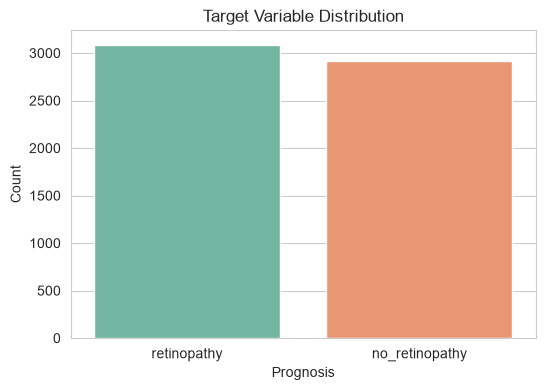

In [314]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="prognosis",
    hue="prognosis",
    palette="Set2",
    legend=False
)

plt.title("Target Variable Distribution")
plt.xlabel("Prognosis")
plt.ylabel("Count")
plt.show()

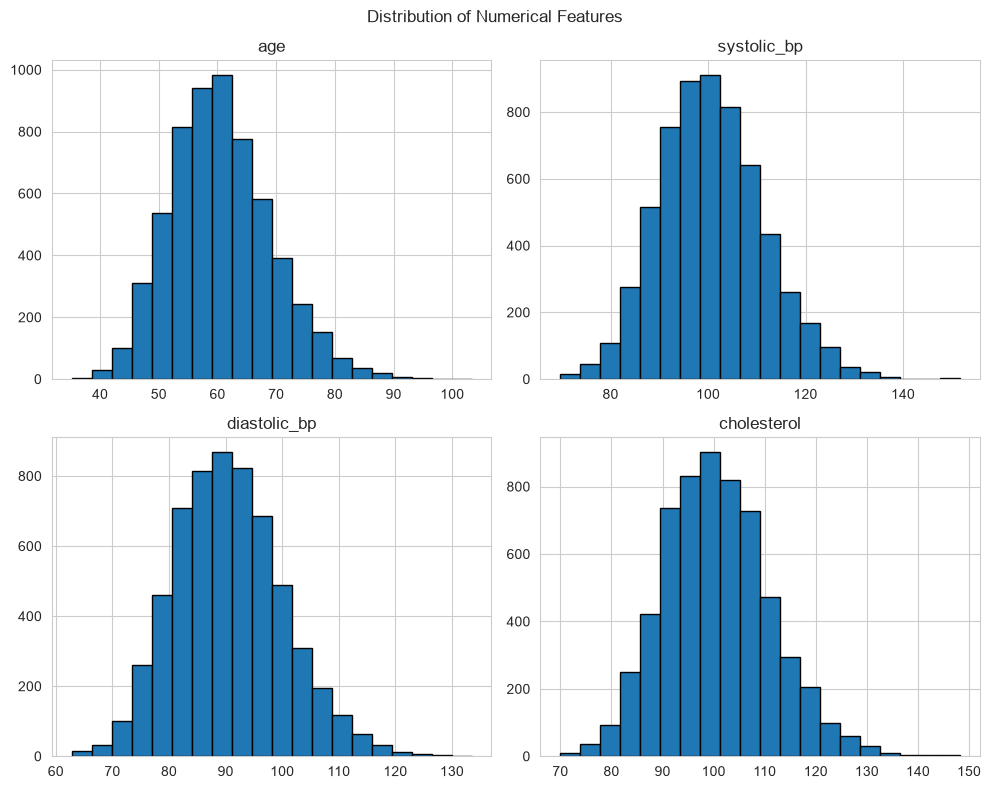

In [315]:
numeric_cols = ["age","systolic_bp","diastolic_bp","cholesterol"]

df[numeric_cols].hist(
    figsize=(10,8),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

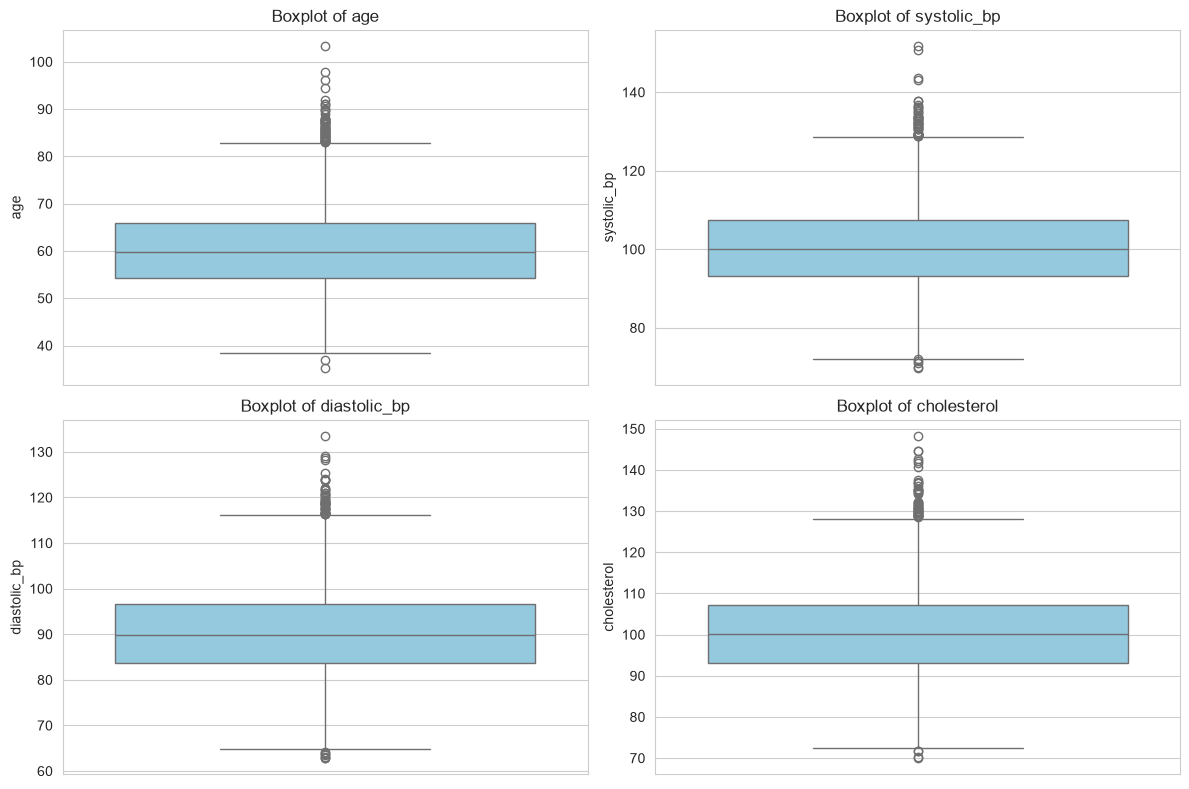

In [316]:
plt.figure(figsize=(12,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

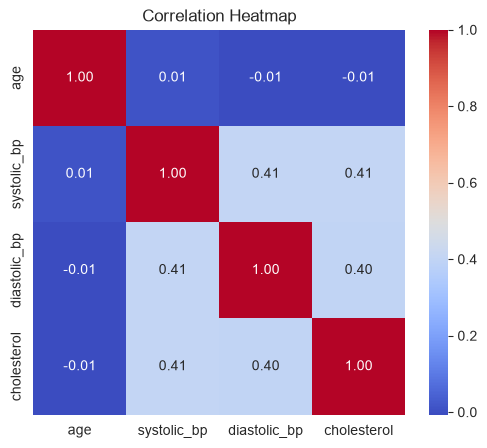

In [317]:
plt.figure(figsize=(6,5))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

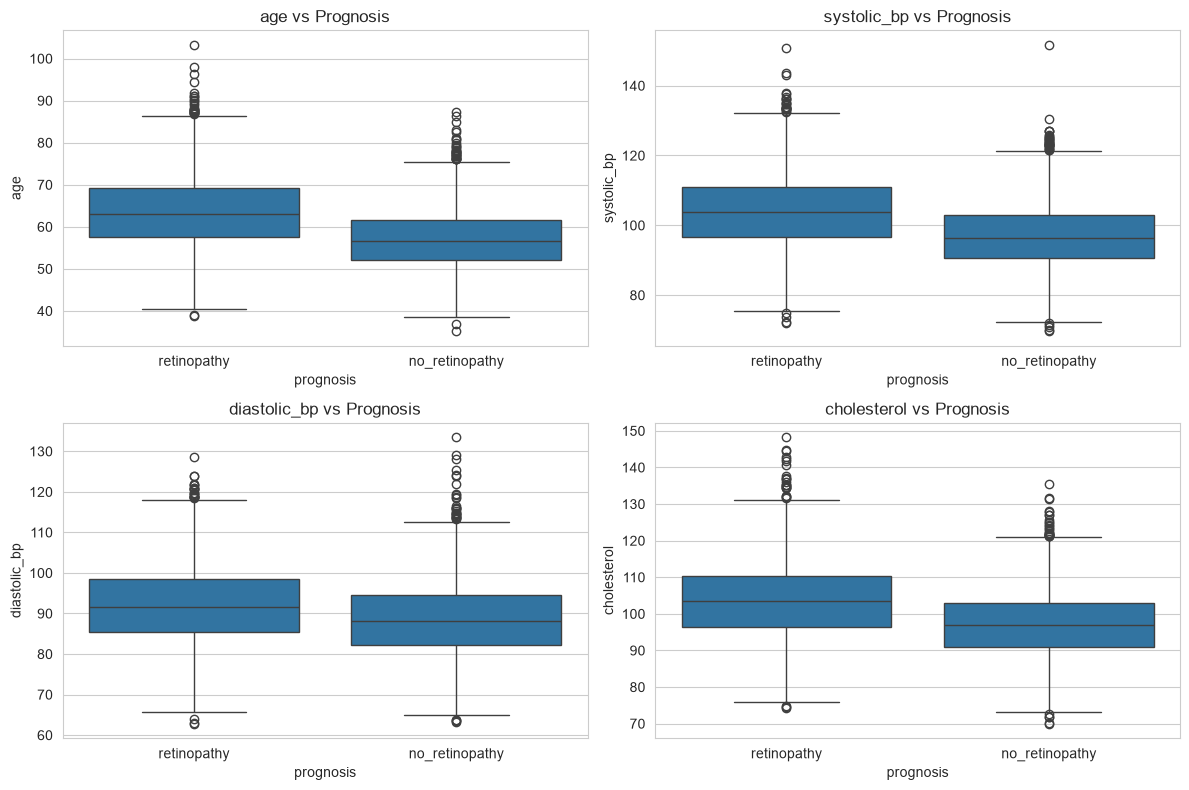

In [318]:
plt.figure(figsize=(12,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(
        x="prognosis",
        y=col,
        data=df
    )
    plt.title(f"{col} vs Prognosis")

plt.tight_layout()
plt.show()

In [319]:
print("Outlier Detection using IQR\n")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Detection using IQR

age: 65 outliers
systolic_bp: 55 outliers
diastolic_bp: 55 outliers
cholesterol: 54 outliers


In [320]:
print("EDA CONCLUSION")


print(f"Total Records : {df.shape[0]}")
print(f"Total Features : {df.shape[1]-1}")
print(f"Target Variable : prognosis")

print("\nNo Missing Values Found.")
print("No Duplicate Records Found.")
print("Target Variable is Binary Classification.")
print("EDA Completed Successfully.")

EDA CONCLUSION
Total Records : 6000
Total Features : 4
Target Variable : prognosis

No Missing Values Found.
No Duplicate Records Found.
Target Variable is Binary Classification.
EDA Completed Successfully.


### Feature Engineering

In [321]:
df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]

print(df[["systolic_bp","diastolic_bp","pulse_pressure"]].head())

   systolic_bp  diastolic_bp  pulse_pressure
0    85.288742     80.021878        5.266865
1    99.379736     84.852361       14.527375
2   111.349455    109.850616        1.498839
3    95.056128     79.666851       15.389277
4   109.154591     90.713220       18.441371


In [322]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0,30,45,60,100],
    labels=["Young","Adult","Middle Age","Senior"]
)

print(df["age_group"].value_counts())

age_group
Senior        2947
Middle Age    2934
Adult          118
Young            0
Name: count, dtype: int64


In [323]:
df["cholesterol_level"] = pd.cut(
    df["cholesterol"],
    bins=[0,200,240,1000],
    labels=["Normal","Borderline","High"]
)

print(df["cholesterol_level"].value_counts())

cholesterol_level
Normal        6000
Borderline       0
High             0
Name: count, dtype: int64


In [324]:
df["bp_category"] = pd.cut(
    df["systolic_bp"],
    bins=[0,120,140,300],
    labels=["Normal","Elevated","High"]
)

print(df["bp_category"].value_counts())

bp_category
Normal      5722
Elevated     274
High           4
Name: count, dtype: int64


In [325]:
df["high_cholesterol"] = (df["cholesterol"] >= 240).astype(int)

print(df["high_cholesterol"].value_counts())

high_cholesterol
0    6000
Name: count, dtype: int64


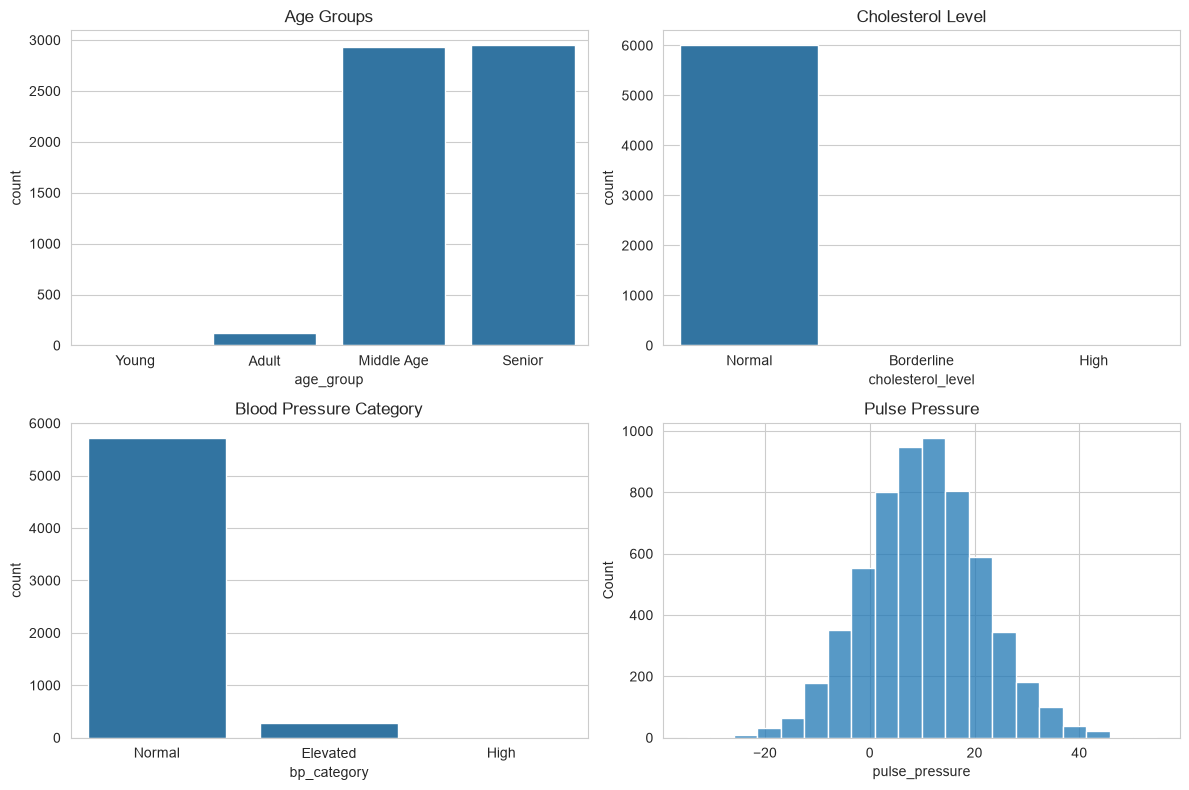

In [326]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.countplot(x="age_group", data=df, ax=axes[0,0])
axes[0,0].set_title("Age Groups")

sns.countplot(x="cholesterol_level", data=df, ax=axes[0,1])
axes[0,1].set_title("Cholesterol Level")

sns.countplot(x="bp_category", data=df, ax=axes[1,0])
axes[1,0].set_title("Blood Pressure Category")

sns.histplot(df["pulse_pressure"], bins=20, ax=axes[1,1])
axes[1,1].set_title("Pulse Pressure")

plt.tight_layout()
plt.show()

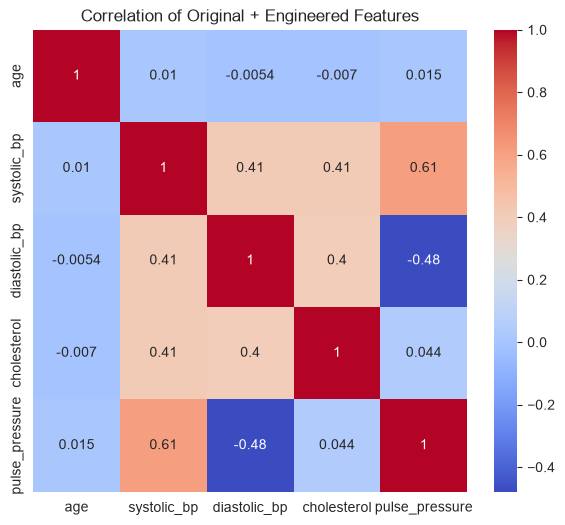

In [327]:
numeric_features = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol",
    "pulse_pressure"
]

plt.figure(figsize=(7,6))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Original + Engineered Features")
plt.show()

### Data Preprocessing

In [328]:
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
df["prognosis"] = le.fit_transform(df["prognosis"])

# One-hot encode categorical engineered features
df = pd.get_dummies(
    df,
    columns=["age_group", "cholesterol_level", "bp_category"],
    drop_first=True
)


### Train-Test Split

In [329]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

In [330]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Building

In [331]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [332]:
# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Support Vector Machine": SVC(
        random_state=42,
        probability=True
    ),

    "Naive Bayes": GaussianNB(),

}

In [333]:
#Train Models
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

print("All models trained successfully.")

All models trained successfully.


In [334]:
# Predicts Retinopathy or No Retinopathy.
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [335]:
#Sample Predictions
for name in predictions:
    print(name)
    print(predictions[name][:10])

Logistic Regression
[0 0 0 0 1 0 0 0 0 0]
Decision Tree
[0 0 0 0 1 0 0 0 0 0]
Random Forest
[0 0 0 0 1 0 0 0 0 0]
Gradient Boosting
[0 0 0 0 1 0 0 0 0 0]
KNN
[0 0 0 1 1 0 0 0 0 0]
Support Vector Machine
[0 0 0 1 1 0 0 0 0 0]
Naive Bayes
[0 0 0 0 1 0 0 0 0 0]


### Model Evaluation

In [336]:
#Import Evaluation Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [337]:
#Create an Evaluation Function
def evaluate_model(name, y_true, y_pred):
    
    print(f"{name}")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

In [338]:
#Evaluate All Models
for name in trained_models.keys():
    evaluate_model(name, y_test, predictions[name])

Logistic Regression
Accuracy : 0.7708
Precision: 0.7879
Recall   : 0.7585
F1 Score : 0.7729

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.78      0.77       583
           1       0.79      0.76      0.77       617

    accuracy                           0.77      1200
   macro avg       0.77      0.77      0.77      1200
weighted avg       0.77      0.77      0.77      1200


Confusion Matrix
[[457 126]
 [149 468]]
Decision Tree
Accuracy : 0.6650
Precision: 0.6813
Recall   : 0.6548
F1 Score : 0.6678

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.68      0.66       583
           1       0.68      0.65      0.67       617

    accuracy                           0.67      1200
   macro avg       0.67      0.67      0.66      1200
weighted avg       0.67      0.67      0.67      1200


Confusion Matrix
[[394 189]
 [213 404]]
Random Forest
Accuracy : 0.7375
Precisio

In [343]:
#Model Comparison Table
results = []

for name in trained_models.keys():

    pred = predictions[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results = pd.DataFrame(results)

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.770833   0.787879  0.758509  0.772915
5  Support Vector Machine  0.755833   0.754717  0.777958  0.766161
3       Gradient Boosting  0.753333   0.756800  0.766613  0.761675
2           Random Forest  0.737500   0.754209  0.726094  0.739884
6             Naive Bayes  0.723333   0.774566  0.651540  0.707746
4                     KNN  0.712500   0.725914  0.708266  0.716981
1           Decision Tree  0.665000   0.681282  0.654781  0.667769


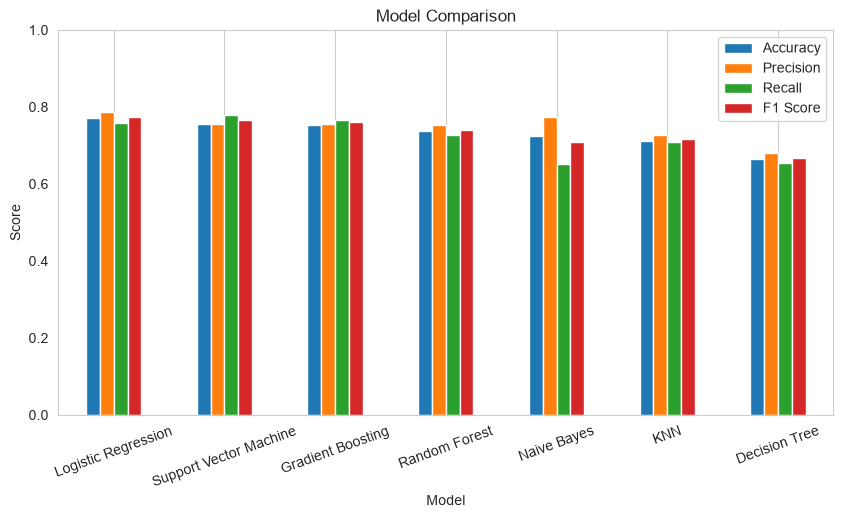

In [344]:
results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

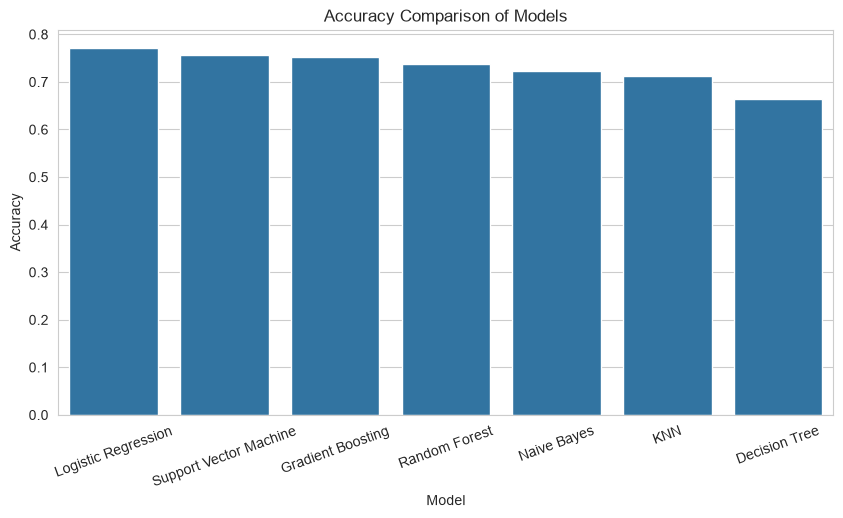

In [339]:
#Accuracy Comparison Graph
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)
plt.title("Accuracy Comparison of Models")
plt.show()

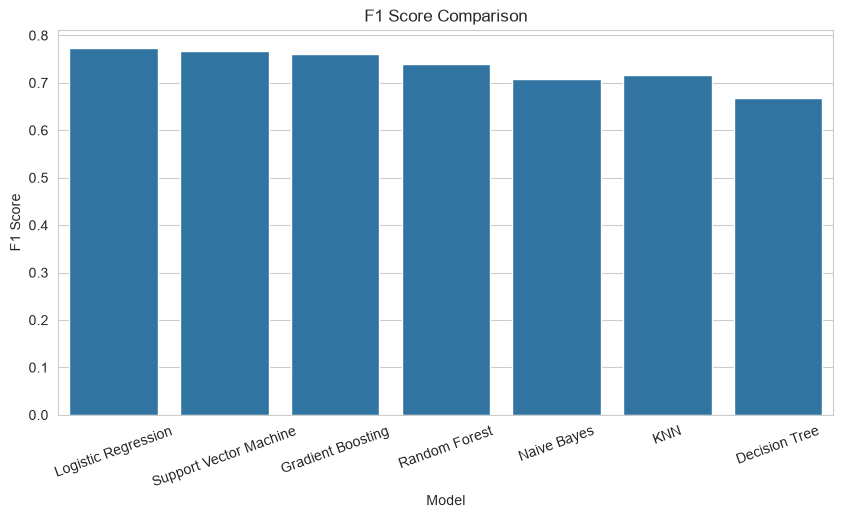

In [340]:
#F1-Score Comparison
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.xticks(rotation=20)
plt.title("F1 Score Comparison")
plt.show()

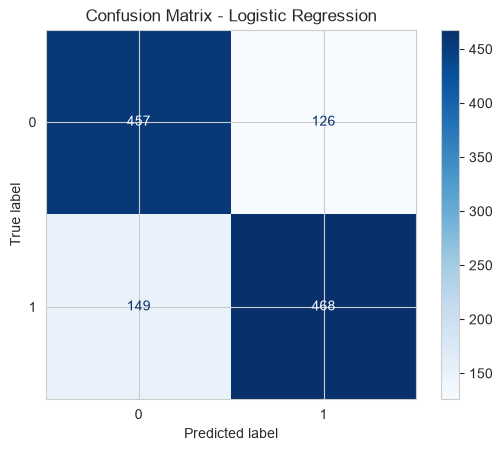

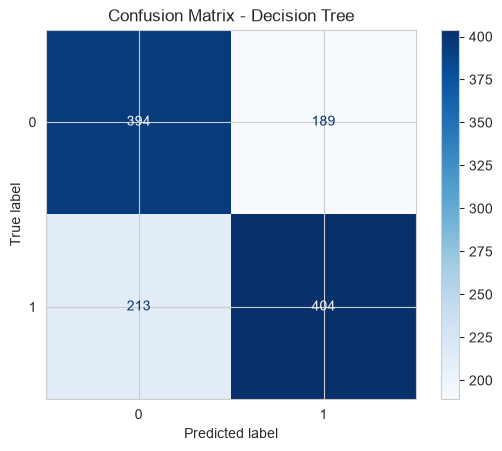

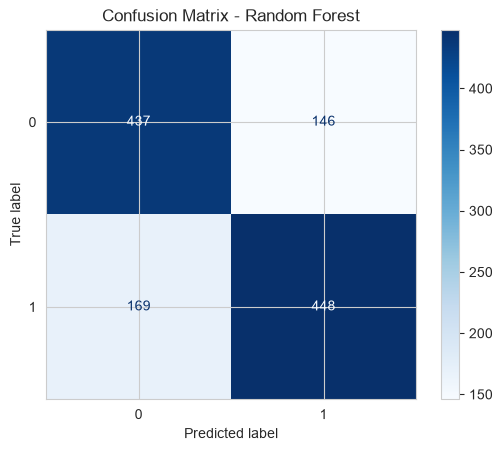

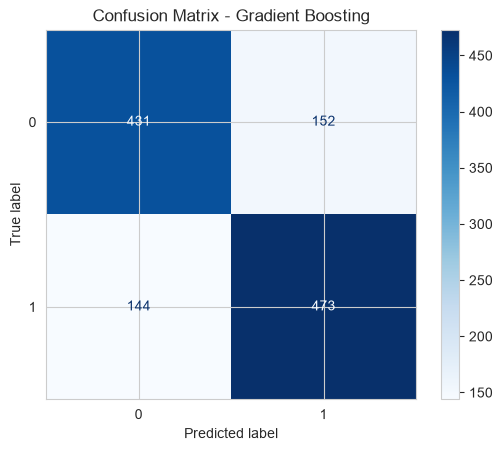

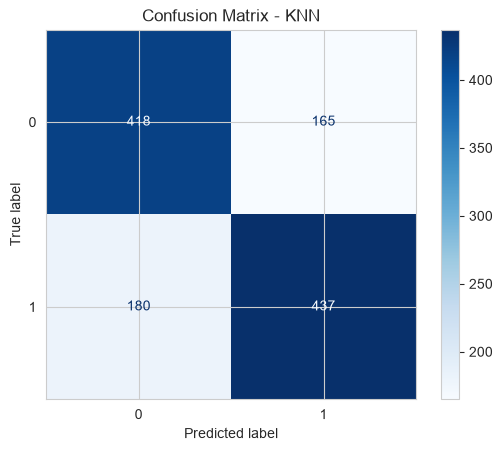

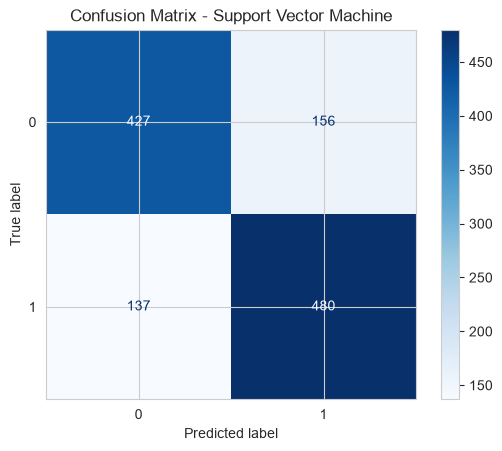

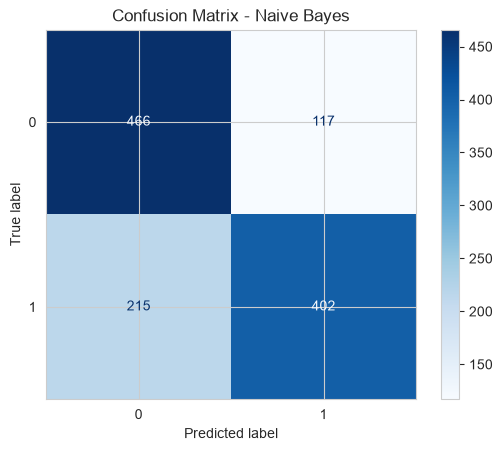

In [341]:
#Confusion Matrix for All Models
for name, model in trained_models.items():

    pred = predictions[name]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

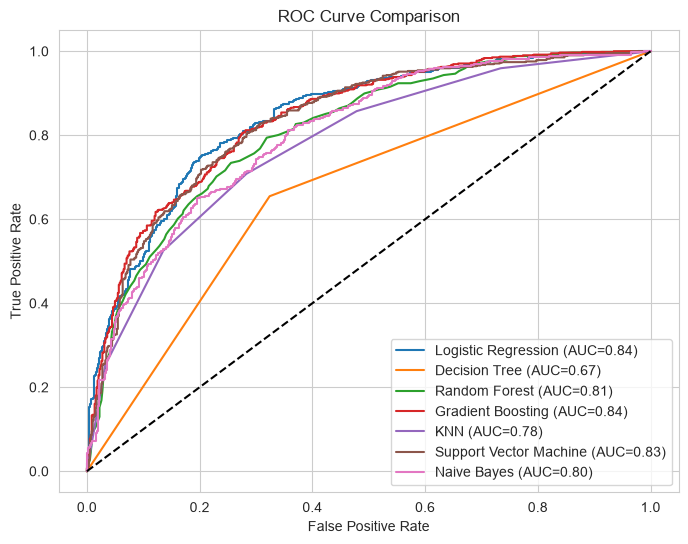

In [342]:
#ROC Curve for All Models
plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [345]:
#Best Model
best_model = results.iloc[0]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model        Logistic Regression
Accuracy                0.770833
Precision               0.787879
Recall                  0.758509
F1 Score                0.772915
Name: 0, dtype: object
